In [25]:
import numpy as np
import matplotlib as plt

In [26]:
def unit_lower_triangular_multiply(L, v):
    # Get the size of the vector and matrix
    n = len(v)
    
    # Initialize the result vector with zeros (as a numpy array)
    w = np.zeros(n)
    
    # Set the first element of the result vector
    w[0] = v[0]
    
    # Loop through each row of the matrix
    for i in range(1, n):
        # Inner product for elements before the diagonal
        for j in range(0, i):
            w[i] += L[i][j] * v[j]
        # Add the vector element for the unit diagonal
        w[i] += v[i]
    
    return w


In [27]:
def unit_lower_triangular_1d_multiply(L_1d, v):
    # Get the size of the vector and initialize result vector w
    n = len(v)
    w = np.zeros(n)
    
    # First element of w is just the first element of v
    w[0] = v[0]
    
    # Counter to track the position in the compressed 1D array
    counter = 0
    
    # Loop through each row starting from the second one (i = 1)
    for i in range(1, n):
        # Initialize index where the current row begins in L_1d
        index = counter
        
        # Inner product for elements before the diagonal
        for j in range(0, i):
            w[i] += L_1d[index] * v[j]
            index += 1
            counter += 1
        
        # Add the vector element for the unit diagonal
        w[i] += v[i]
    
    return w

In [28]:
def lower_banded_multiply(L_banded, v_banded):
    # Get the size of the vector and initialize result vector w
    n = len(v_banded)
    w_banded = np.zeros(n)
    
    # Simple assignments for the first two rows
    w_banded[0] = v_banded[0]
    w_banded[1] = L_banded[0] * v_banded[0]
    
    # Initialize the index for the compressed row form
    index = 1
    
    # Loop for rows starting from the third one
    for i in range(2, n):
        # Inner product for the banded part (two diagonals)
        w_banded[i] += L_banded[index] * v_banded[i - 2]
        w_banded[i] += L_banded[index + 1] * v_banded[i - 1]
        
        # Update index for next row in L_banded
        index += 2
    
    # Add the vector element for the unit diagonal
    for i in range(1, n):
        w_banded[i] += v_banded[i]
    
    return w_banded

# Example usage
L_banded = np.array([3, 4, 5, 6, 7, 8,9])  # Compressed lower banded matrix
v_banded = np.array([2, 2, 3, 4, 5])  # Vector

result = lower_banded_multiply(L_banded, v_banded)
print(result)  # Output the result vector


[ 2.  8. 21. 37. 65.]


In [34]:
def lu_multiply(LU):
    # Get the size of the matrix
    n = LU.shape[0]
    
    # Initialize the result matrix M with zeros
    M = np.zeros((n, n))
    
    # Compute the first row directly from U
    for i in range(n):
        M[0][i] = LU[0][i]
    
    # Compute the first column of M
    for i in range(1, n):
        M[i][0] = LU[i][0] * LU[0][0]
    
    # Compute the rest of the matrix
    for i in range(1, n):
        for j in range(1, n):
            # Calculate the minimum limit for iteration
            min_val = j+1
            if((min_val - i) >0):
                min_val = i
            
            # Inner product for the lower and upper parts of the matrix
            index = 0
            for k in range(min_val):
                M[i][j] += LU[i][k] * LU[k][j]
                index += 1
            
            # Handle the diagonal element (implicitly 1 for L)
            if (i <= j):
                M[i][j] += LU[index][j]
    
    return M


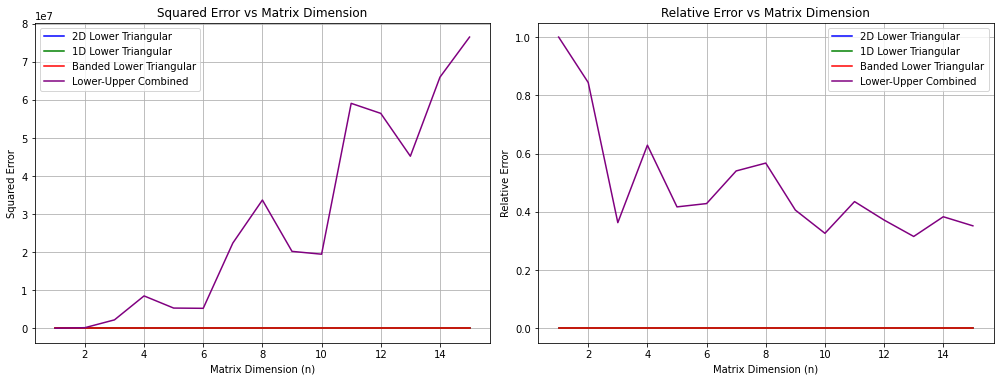

In [44]:
# Function to convert 1D compressed lower triangular matrix to 2D
def compressed_1d_to_2d(L_1d, n):
    """Convert a compressed 1D lower triangular matrix back to a 2D lower unit matrix."""
    L_2d = np.eye(n)  # Start with an identity matrix (diagonal ones)
    idx = 0  # Index for the 1D compressed matrix

    for i in range(1, n):  # Start from row 1, as row 0 is the diagonal
        for j in range(i):
            L_2d[i, j] = L_1d[idx]
            idx += 1

    return L_2d

# Function to convert 1D banded lower triangular matrix to 2D
def banded_to_2d(L_banded, n):
    """Convert a banded lower triangular matrix stored in 1D back to 2D."""
    L_2d = np.eye(n)  # Start with an identity matrix (diagonal ones)
    idx = 0  # Index for the 1D banded matrix

    for i in range(1, n):
        # First element for row i (i-2 diagonal)
        if i >= 2:
            L_2d[i, i-2] = L_banded[idx]
            idx += 1
        # Second element for row i (i-1 diagonal)
        L_2d[i, i-1] = L_banded[idx]
        idx += 1

    return L_2d

# Function to split a random matrix into unit lower and upper triangular matrices
def random_matrix_to_lu(LU_random, n):
    """Convert a random 2D array into a combined unit lower and upper triangular matrix."""
    L = np.tril(LU_random)  # Extract lower triangular part
    np.fill_diagonal(L, 1)  # Set diagonal to 1 for the unit lower matrix
    U = np.triu(LU_random)  # Extract upper triangular part
    return L, U

# Error calculation functions
def squared_error(output, reference):
    return np.sum((output - reference) ** 2)

def relative_error(output, reference):
    return np.linalg.norm(output - reference) / np.linalg.norm(reference)

# Full driver function to test and plot errors for all 4 subroutines
def driver():
    dimensions = list(range(1, 16))  # Only for dimension 1 to 15
    
    squared_errors_2d = []
    relative_errors_2d = []

    squared_errors_1d = []
    relative_errors_1d = []

    squared_errors_banded = []
    relative_errors_banded = []

    squared_errors_lu = []
    relative_errors_lu = []

    for n in dimensions:
        # Generate random values between [-50, 50] for the vector
        v = np.random.uniform(-50, 50, size=n)
        
        # Unit Lower (2D) matrix multiply a vector
        L_2d = np.tril(np.random.uniform(-50, 50, (n, n)))  # Random unit lower triangular matrix
        np.fill_diagonal(L_2d, 1)  # Ensure it is unit lower triangular
        output_2d = unit_lower_triangular_multiply(L_2d, v)
        reference_2d = np.dot(L_2d, v)
        error_2d = squared_error(output_2d, reference_2d)
        rel_error_2d = relative_error(output_2d, reference_2d)
        squared_errors_2d.append(error_2d)
        relative_errors_2d.append(rel_error_2d)

        # Unit Lower (1D compressed random vector of size (n)(n-1)/2) matrix multiply a vector
        size_1d = (n * (n - 1)) // 2  # Length of the compressed form of the lower triangular part
        L_1d = np.random.uniform(-50, 50, size=size_1d)  # Generate random 1D array
        output_1d = unit_lower_triangular_1d_multiply(L_1d, v)
        L_1d_2d = compressed_1d_to_2d(L_1d, n)  # Convert 1D back to 2D for reference
        reference_1d = np.dot(L_1d_2d, v)
        error_1d = squared_error(output_1d, reference_1d)
        rel_error_1d = relative_error(output_1d, reference_1d)
        squared_errors_1d.append(error_1d)
        relative_errors_1d.append(rel_error_1d)

        # Unit Lower banded (row compressed) multiply a vector (2n-3 random values)
        if n > 2:
            L_banded = np.random.uniform(-50, 50, size=2*n - 3)  # Generate random banded matrix of size 2n-3
            output_banded = lower_banded_multiply(L_banded, v)
            L_banded_2d = banded_to_2d(L_banded, n)  # Convert 1D banded back to 2D for reference
            reference_banded = np.dot(L_banded_2d, v)
            error_banded = squared_error(output_banded, reference_banded)
            rel_error_banded = relative_error(output_banded, reference_banded)
        else:
            error_banded = 0
            rel_error_banded = 0
        squared_errors_banded.append(error_banded)
        relative_errors_banded.append(rel_error_banded)

        # Lower-Upper Combined: Generate random matrix, split into L and U
        LU_random = np.random.uniform(-50, 50, (n, n))  # Random 2D matrix
        L, U = random_matrix_to_lu(LU_random, n)  # Convert to L (unit lower) and U (upper)
        LU_combined = np.tril(LU_random) + np.triu(LU_random)  # Combine L and U for the subroutine
        output_lu = lu_multiply(LU_combined)
        
        # Reference: Multiply L and U directly for comparison
        reference_lu = np.dot(L, U)
        error_lu = squared_error(output_lu, reference_lu)
        rel_error_lu = relative_error(output_lu, reference_lu)
        squared_errors_lu.append(error_lu)
        relative_errors_lu.append(rel_error_lu)

    # Plotting the squared and relative errors for all 4 subroutines
    plt.figure(figsize=(14, 10))
    
    # Squared Error plots
    plt.subplot(2, 2, 1)
    plt.plot(dimensions, squared_errors_2d, label='2D Lower Triangular', color='b')
    plt.plot(dimensions, squared_errors_1d, label='1D Lower Triangular', color='g')
    plt.plot(dimensions, squared_errors_banded, label='Banded Lower Triangular', color='r')
    plt.plot(dimensions, squared_errors_lu, label='Lower-Upper Combined', color='purple')
    plt.xlabel('Matrix Dimension (n)')
    plt.ylabel('Squared Error')
    plt.title('Squared Error vs Matrix Dimension')
    plt.legend()
    plt.grid(True)

    # Relative Error plots
    plt.subplot(2, 2, 2)
    plt.plot(dimensions, relative_errors_2d, label='2D Lower Triangular', color='b')
    plt.plot(dimensions, relative_errors_1d, label='1D Lower Triangular', color='g')
    plt.plot(dimensions, relative_errors_banded, label='Banded Lower Triangular', color='r')
    plt.plot(dimensions, relative_errors_lu, label='Lower-Upper Combined', color='purple')
    plt.xlabel('Matrix Dimension (n)')
    plt.ylabel('Relative Error')
    plt.title('Relative Error vs Matrix Dimension')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Run the driver
driver()

